In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [2]:
import string
import re
import pymorphy3
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.probability import FreqDist

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/3b703cd6-2481-4285-bdc3-
[nltk_data]     8bea7b95bc92/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer,CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF

In [4]:
stop_words = stopwords.words('russian')
morph = pymorphy3.MorphAnalyzer()

In [5]:
def tokenize_text(raw_text: str):
    words = raw_text.split()
    re_punc = re.compile('[%s]'%re.escape(string.punctuation))
    stripped = [re_punc.sub('', w) for w in words]
    words_lower = [word.lower() for word in stripped]
    words_alpha = [word for word in words_lower if word.isalpha()]
    words_stop = [word for word in words_alpha if not word in stop_words]
    words_morph = [morph.parse(word)[0].normal_form for word in words_stop]
    tokens = [word for word in words_morph if len(word)>3]
    
    return tokens

In [7]:
df_posts = pd.read_csv('post_election.csv', index_col = 0)
df_posts.head()

,0,1,2,3,4
0,2024-03-10 23:08:04,7302,843899609,843899609,Топ событий предстоящей недели 11-17 марта 202...
1,2024-03-10 23:07:32,32594,140104156,140104156,Сообщение в канале «Поддубный |Z|О|V| edition»...
2,2024-03-10 23:07:02,494,338922645,338922645,С большим удовольствием погулял сегодня на лыж...
3,2024-03-10 23:05:47,5179,1724015,1724015,Вот за эту статью Олега Орлова приговорили к д...
4,2024-03-10 23:05:38,7298,843899609,843899609,Преемник:🔥🔥 Preemnik. Главное за неделюБольшая...


In [13]:
df_posts.columns = ['date','user_ID', 'post_ID', 'post_ID-copy', 'post_text']
df_posts.head()

,date,user_ID,post_ID,post_ID-copy,post_text
0,2024-03-10 23:08:04,7302,843899609,843899609,Топ событий предстоящей недели 11-17 марта 202...
1,2024-03-10 23:07:32,32594,140104156,140104156,Сообщение в канале «Поддубный |Z|О|V| edition»...
2,2024-03-10 23:07:02,494,338922645,338922645,С большим удовольствием погулял сегодня на лыж...
3,2024-03-10 23:05:47,5179,1724015,1724015,Вот за эту статью Олега Орлова приговорили к д...
4,2024-03-10 23:05:38,7298,843899609,843899609,Преемник:🔥🔥 Preemnik. Главное за неделюБольшая...


In [8]:
df_comments = pd.read_csv('comment.csv', index_col = 0)
df_comments.head()

,post_id,comments_text
0,12103.0,"Зачем эта игра в ""демократию"" ?! Результат уже..."
1,12103.0,За Бориса Борисовича Надеждина!!!
2,12103.0,"Я бы вообще , голосовал за Ярослава Нилова !"
3,12103.0,"Интересно, если бы хоть раз выборы прошли чест..."
4,12103.0,Выборы - без выбора. Вообще не за кого!!!


In [9]:
df_posts.shape

(8152, 5)

In [14]:
tokenized = df_posts['post_text'].apply(tokenize_text)

In [16]:
df_posts = df_posts.assign(tokenized = tokenized)
df_posts.head()

,date,user_ID,post_ID,post_ID-copy,post_text,tokenized
0,2024-03-10 23:08:04,7302,843899609,843899609,Топ событий предстоящей недели 11-17 марта 202...,"[событие, предстоящий, неделя, март, март, пон..."
1,2024-03-10 23:07:32,32594,140104156,140104156,Сообщение в канале «Поддубный |Z|О|V| edition»...,"[сообщение, канал, такой, эпизод, часто, остав..."
2,2024-03-10 23:07:02,494,338922645,338922645,С большим удовольствием погулял сегодня на лыж...,"[больший, удовольствие, погулять, сегодня, лыж..."
3,2024-03-10 23:05:47,5179,1724015,1724015,Вот за эту статью Олега Орлова приговорили к д...,"[статья, олег, орлов, приговорить, половина, л..."
4,2024-03-10 23:05:38,7298,843899609,843899609,Преемник:🔥🔥 Preemnik. Главное за неделюБольшая...,"[preemnik, главное, неделюбольший, политически..."


In [19]:
df_posts.to_csv ('posts_tokenized.csv')

In [20]:
words_list_posts = list (df_posts['tokenized'])

In [22]:
 all_words_posts = np.concatenate (words_list_posts)

In [24]:
all_words_freq_posts = FreqDist(all_words_posts)

In [25]:
print(f'Наиболее популярные слова: {all_words_freq_posts.most_common(100)}')
print (f'\nОбщее количество уникальных слов: ', len(all_words_freq_posts.keys()))

Наиболее популярные слова: [('выборы', 11623), ('президент', 10772), ('россия', 10718), ('который', 6925), ('страна', 4449), ('свой', 4333), ('март', 4252), ('голосование', 3743), ('мочь', 2958), ('день', 2640), ('каждый', 2631), ('место', 2612), ('событие', 2599), ('проголосовать', 2587), ('также', 2529), ('область', 2475), ('важный', 2344), ('участок', 2280), ('житель', 2258), ('проект', 2250), ('городской', 2232), ('российский', 2166), ('избирательный', 2138), ('участие', 2128), ('военный', 2033), ('владимир', 2015), ('регион', 2009), ('гражданин', 1957), ('путин', 1924), ('быть', 1842), ('голос', 1823), ('именно', 1765), ('республика', 1762), ('будущее', 1723), ('федерация', 1686), ('гражданский', 1667), ('сделать', 1623), ('другой', 1590), ('площадь', 1581), ('власть', 1542), ('пройти', 1522), ('политический', 1521), ('этот', 1519), ('голосовать', 1515), ('местный', 1501), ('документ', 1485), ('бабушкин', 1477), ('принять', 1454), ('адрес', 1408), ('человек', 1366), ('новый', 1321

/tmp/ipykernel_401/1397073842.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation = 45)


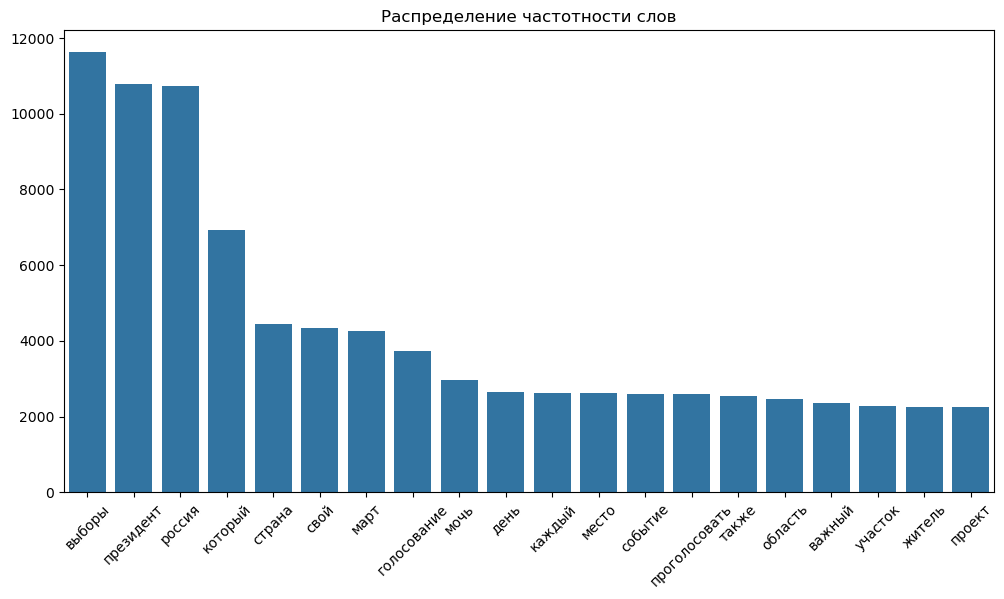

In [26]:
count, words = [],[]
for word in all_words_freq_posts.most_common(20):
    words.append(word[0])
    count.append(word[1])
fig,ax = plt.subplots(figsize = (12,6))
ax = sns.barplot(x = words, y = count)
ax.set_xticklabels(ax.get_xticklabels(), rotation = 45)
ax.set_title('Распределение частотности слов')
plt.show()

In [29]:
df = pd.read_csv('posts_tokenized.csv', index_col = 0)
df.head()

,date,user_ID,post_ID,post_ID-copy,post_text,tokenized
0,2024-03-10 23:08:04,7302,843899609,843899609,Топ событий предстоящей недели 11-17 марта 202...,"['событие', 'предстоящий', 'неделя', 'март', '..."
1,2024-03-10 23:07:32,32594,140104156,140104156,Сообщение в канале «Поддубный |Z|О|V| edition»...,"['сообщение', 'канал', 'такой', 'эпизод', 'час..."
2,2024-03-10 23:07:02,494,338922645,338922645,С большим удовольствием погулял сегодня на лыж...,"['больший', 'удовольствие', 'погулять', 'сегод..."
3,2024-03-10 23:05:47,5179,1724015,1724015,Вот за эту статью Олега Орлова приговорили к д...,"['статья', 'олег', 'орлов', 'приговорить', 'по..."
4,2024-03-10 23:05:38,7298,843899609,843899609,Преемник:🔥🔥 Preemnik. Главное за неделюБольшая...,"['preemnik', 'главное', 'неделюбольший', 'поли..."


In [31]:
textt = ','.join(word for word in df_posts['tokenized'])

TypeError: sequence item 0: expected str instance, list found

In [30]:
textt = ','.join(word for word in df['tokenized'])

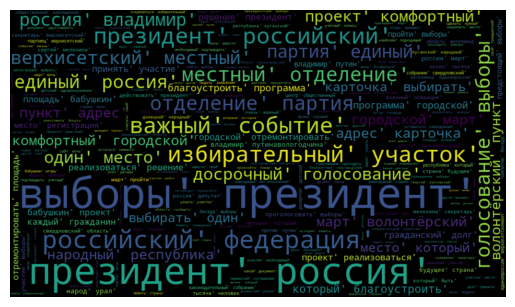

In [33]:
wordcloud = WordCloud (width = 950, height = 550).generate(textt)
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')
plt.show()

In [51]:
stop_words_ex = ['выборы','президент', 'который','свой','также','россия','каждый']

In [46]:
def full_stop_words (text):
    words = [word for word in text if not word in stop_words_ex]
    return words

In [52]:
pure_tokens = df_posts['tokenized'].apply(full_stop_words)
df = df_posts.assign(pure_tokens=pure_tokens)
df.head()

,date,user_ID,post_ID,post_ID-copy,post_text,tokenized,pure_tokens
0,2024-03-10 23:08:04,7302,843899609,843899609,Топ событий предстоящей недели 11-17 марта 202...,"[событие, предстоящий, неделя, март, март, пон...","[событие, предстоящий, неделя, март, март, пон..."
1,2024-03-10 23:07:32,32594,140104156,140104156,Сообщение в канале «Поддубный |Z|О|V| edition»...,"[сообщение, канал, такой, эпизод, часто, остав...","[сообщение, канал, такой, эпизод, часто, остав..."
2,2024-03-10 23:07:02,494,338922645,338922645,С большим удовольствием погулял сегодня на лыж...,"[больший, удовольствие, погулять, сегодня, лыж...","[больший, удовольствие, погулять, сегодня, лыж..."
3,2024-03-10 23:05:47,5179,1724015,1724015,Вот за эту статью Олега Орлова приговорили к д...,"[статья, олег, орлов, приговорить, половина, л...","[статья, олег, орлов, приговорить, половина, л..."
4,2024-03-10 23:05:38,7298,843899609,843899609,Преемник:🔥🔥 Preemnik. Главное за неделюБольшая...,"[preemnik, главное, неделюбольший, политически...","[preemnik, главное, неделюбольший, политически..."


In [53]:
words_list = list(df['pure_tokens'])
all_words = np.concatenate(words_list)

In [54]:
all_words_freq = FreqDist(all_words)
print(f'Наиболее популярные слова: {all_words_freq.most_common(100)}')
print (f'\nОбщее количество уникальных слов: ', len(all_words_freq.keys()))

Наиболее популярные слова: [('страна', 4449), ('март', 4252), ('голосование', 3743), ('мочь', 2958), ('день', 2640), ('место', 2612), ('событие', 2599), ('проголосовать', 2587), ('область', 2475), ('важный', 2344), ('участок', 2280), ('житель', 2258), ('проект', 2250), ('городской', 2232), ('российский', 2166), ('избирательный', 2138), ('участие', 2128), ('военный', 2033), ('владимир', 2015), ('регион', 2009), ('гражданин', 1957), ('путин', 1924), ('быть', 1842), ('голос', 1823), ('именно', 1765), ('республика', 1762), ('будущее', 1723), ('федерация', 1686), ('гражданский', 1667), ('сделать', 1623), ('другой', 1590), ('площадь', 1581), ('власть', 1542), ('пройти', 1522), ('политический', 1521), ('этот', 1519), ('голосовать', 1515), ('местный', 1501), ('документ', 1485), ('бабушкин', 1477), ('принять', 1454), ('адрес', 1408), ('человек', 1366), ('новый', 1321), ('время', 1315), ('один', 1303), ('проходить', 1299), ('район', 1291), ('развитие', 1282), ('очень', 1279), ('народ', 1273), ('

/tmp/ipykernel_401/2021039292.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation = 45)


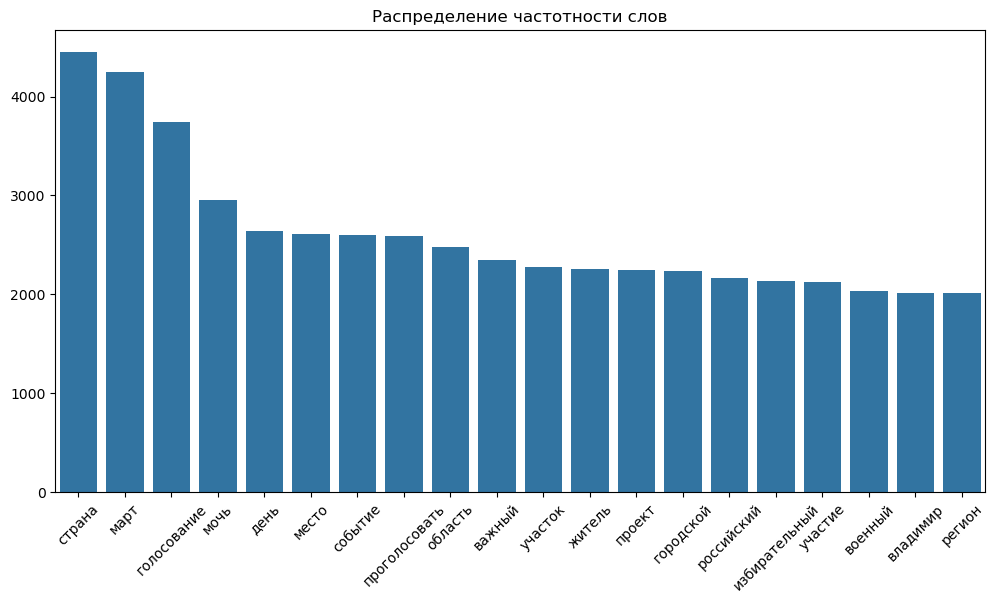

In [55]:
count, words = [],[]
for word in all_words_freq.most_common(20):
    words.append(word[0])
    count.append(word[1])
fig,ax = plt.subplots(figsize = (12,6))
ax = sns.barplot(x = words, y = count)
ax.set_xticklabels(ax.get_xticklabels(), rotation = 45)
ax.set_title('Распределение частотности слов')
plt.show()

In [56]:
df.to_csv ('posts_pure_tokens.csv')

In [5]:
df = pd.read_csv('posts_pure_tokens.csv', index_col = 0)
df.head()

,date,user_ID,post_ID,post_ID-copy,post_text,tokenized,pure_tokens
0,2024-03-10 23:08:04,7302,843899609,843899609,Топ событий предстоящей недели 11-17 марта 202...,"['событие', 'предстоящий', 'неделя', 'март', '...","['событие', 'предстоящий', 'неделя', 'март', '..."
1,2024-03-10 23:07:32,32594,140104156,140104156,Сообщение в канале «Поддубный |Z|О|V| edition»...,"['сообщение', 'канал', 'такой', 'эпизод', 'час...","['сообщение', 'канал', 'такой', 'эпизод', 'час..."
2,2024-03-10 23:07:02,494,338922645,338922645,С большим удовольствием погулял сегодня на лыж...,"['больший', 'удовольствие', 'погулять', 'сегод...","['больший', 'удовольствие', 'погулять', 'сегод..."
3,2024-03-10 23:05:47,5179,1724015,1724015,Вот за эту статью Олега Орлова приговорили к д...,"['статья', 'олег', 'орлов', 'приговорить', 'по...","['статья', 'олег', 'орлов', 'приговорить', 'по..."
4,2024-03-10 23:05:38,7298,843899609,843899609,Преемник:🔥🔥 Preemnik. Главное за неделюБольшая...,"['preemnik', 'главное', 'неделюбольший', 'поли...","['preemnik', 'главное', 'неделюбольший', 'поли..."


In [58]:
textt = ','.join(word for word in df['pure_tokens'])


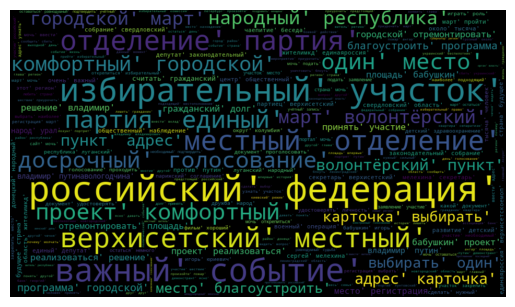

In [59]:
wordcloud = WordCloud (width = 950, height = 550).generate(textt)
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')
plt.show()

# Тематическое моделирование

In [7]:
count_vect = CountVectorizer (max_df=0.8, min_df= 3, stop_words = None)
doc_term_matrix = count_vect.fit_transform(df['pure_tokens'])

In [8]:
LDA_2 = LatentDirichletAllocation (n_components=2, random_state = 42)
LDA_2.fit(doc_term_matrix)

,n_components,2
,doc_topic_prior,None
,topic_word_prior,None
,learning_method,'batch'
,learning_decay,0.7
,learning_offset,10.0
,max_iter,10
,batch_size,128
,evaluate_every,-1
,total_samples,1000000.0
,perp_tol,0.1


In [9]:
for i, topic in enumerate (LDA_2.components_):
    print (f'Top 10 words for topic No {i}: ')
    print ([count_vect.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print ('\n')

Top 10 words for topic No 0: 
['регион', 'российский', 'участок', 'городской', 'проголосовать', 'проект', 'мочь', 'место', 'голосование', 'март']


Top 10 words for topic No 1: 
['очень', 'область', 'другой', 'быть', 'политический', 'март', 'власть', 'голос', 'событие', 'страна']




In [10]:
LDA_3 = LatentDirichletAllocation (n_components=3, random_state = 42)
LDA_3.fit(doc_term_matrix)

,n_components,3
,doc_topic_prior,None
,topic_word_prior,None
,learning_method,'batch'
,learning_decay,0.7
,learning_offset,10.0
,max_iter,10
,batch_size,128
,evaluate_every,-1
,total_samples,1000000.0
,perp_tol,0.1


In [11]:
for i, topic in enumerate (LDA_3.components_):
    print (f'Top 10 words for topic No {i}: ')
    print ([count_vect.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print ('\n')

Top 10 words for topic No 0: 
['проголосовать', 'день', 'гражданин', 'область', 'паспорт', 'военный', 'закон', 'документ', 'голосование', 'регион']


Top 10 words for topic No 1: 
['проголосовать', 'голосование', 'единый', 'местный', 'партия', 'народ', 'политический', 'событие', 'страна', 'март']


Top 10 words for topic No 2: 
['адрес', 'владимир', 'избирательный', 'участок', 'март', 'городской', 'проект', 'место', 'страна', 'мочь']




In [13]:
topic_values = LDA_3.transform(doc_term_matrix)
topic_values.shape

(8152, 3)

In [14]:
df['Topic_LDA'] = topic_values.argmax(axis=1)
df.head()

,date,user_ID,post_ID,post_ID-copy,post_text,tokenized,pure_tokens,Topic_LDA
0,2024-03-10 23:08:04,7302,843899609,843899609,Топ событий предстоящей недели 11-17 марта 202...,"['событие', 'предстоящий', 'неделя', 'март', '...","['событие', 'предстоящий', 'неделя', 'март', '...",2
1,2024-03-10 23:07:32,32594,140104156,140104156,Сообщение в канале «Поддубный |Z|О|V| edition»...,"['сообщение', 'канал', 'такой', 'эпизод', 'час...","['сообщение', 'канал', 'такой', 'эпизод', 'час...",2
2,2024-03-10 23:07:02,494,338922645,338922645,С большим удовольствием погулял сегодня на лыж...,"['больший', 'удовольствие', 'погулять', 'сегод...","['больший', 'удовольствие', 'погулять', 'сегод...",2
3,2024-03-10 23:05:47,5179,1724015,1724015,Вот за эту статью Олега Орлова приговорили к д...,"['статья', 'олег', 'орлов', 'приговорить', 'по...","['статья', 'олег', 'орлов', 'приговорить', 'по...",2
4,2024-03-10 23:05:38,7298,843899609,843899609,Преемник:🔥🔥 Preemnik. Главное за неделюБольшая...,"['preemnik', 'главное', 'неделюбольший', 'поли...","['preemnik', 'главное', 'неделюбольший', 'поли...",2


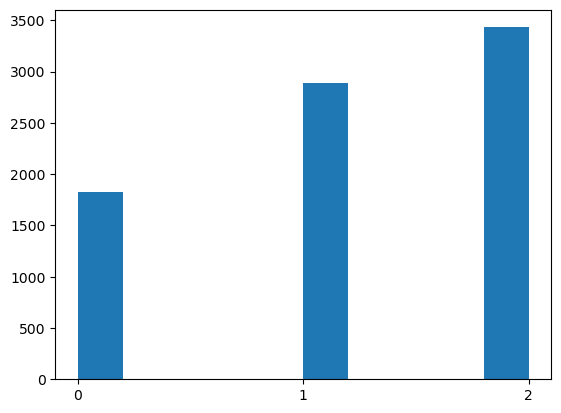

In [15]:
plt.hist(df['Topic_LDA'])
plt.xticks ([0,1,2]);

In [16]:
topic_1 = df [df['Topic_LDA']==0]
topic_1.shape

(1830, 8)

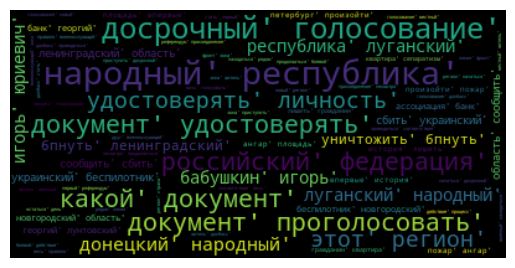

In [17]:
textt = ''.join(w for w in topic_1.pure_tokens)
wordcloud = WordCloud().generate(textt)
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')
plt.show()

In [18]:
topic_2 = df [df['Topic_LDA']==1]
topic_2.shape

(2889, 8)

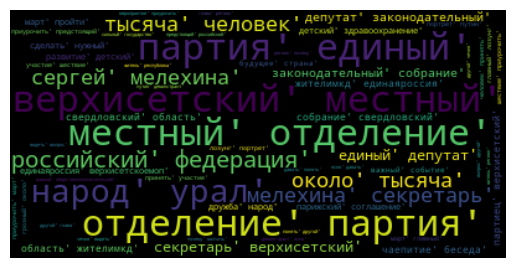

In [19]:
textt = ''.join(w for w in topic_2.pure_tokens)
wordcloud = WordCloud().generate(textt)
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')
plt.show()

In [20]:
topic_3 = df [df['Topic_LDA']==2]
topic_3.shape

(3433, 8)

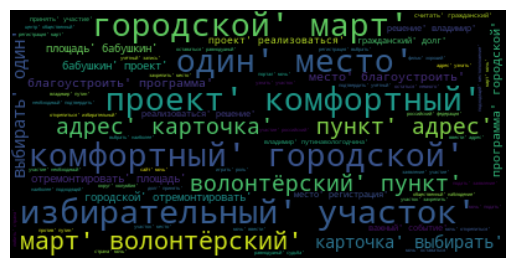

In [21]:
textt = ''.join(w for w in topic_3.pure_tokens)
wordcloud = WordCloud().generate(textt)
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')
plt.show()

In [22]:
tfidf_vect = TfidfVectorizer (max_df = 1.0, min_df = 2, stop_words = None)
doc_term_matrix = tfidf_vect.fit_transform(df['pure_tokens'])

In [26]:
nmf = NMF(n_components = 3, random_state = 42)
nmf.fit(doc_term_matrix)

,n_components,3
,init,None
,solver,'cd'
,beta_loss,'frobenius'
,tol,0.0001
,max_iter,200
,random_state,42
,alpha_W,0.0
,alpha_H,'same'
,l1_ratio,0.0
,verbose,0


In [27]:
for i, topic in enumerate (nmf.components_):
    print (f'Top 10 words for topic No {i}: ')
    print ([tfidf_vect.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print ('\n')

Top 10 words for topic No 0: 
['карточка', 'программа', 'выбирать', 'отремонтировать', 'реализоваться', 'комфортный', 'благоустроить', 'волонтёрский', 'проект', 'городской']


Top 10 words for topic No 1: 
['судьба', 'федерация', 'будущее', 'долг', 'событие', 'гражданский', 'российский', 'считать', 'важный', 'страна']


Top 10 words for topic No 2: 
['учётный', 'открепиться', 'портал', 'выбрать', 'место', 'заявление', 'избирательный', 'мочь', 'регистрация', 'участок']




In [28]:
topic_values = nmf.transform(doc_term_matrix)
topic_values.shape

(8152, 3)

In [30]:
df['Topic_NMF'] = topic_values.argmax(axis = 1)
df.head()

,date,user_ID,post_ID,post_ID-copy,post_text,tokenized,pure_tokens,Topic_LDA,Topic_NMF
0,2024-03-10 23:08:04,7302,843899609,843899609,Топ событий предстоящей недели 11-17 марта 202...,"['событие', 'предстоящий', 'неделя', 'март', '...","['событие', 'предстоящий', 'неделя', 'март', '...",2,1
1,2024-03-10 23:07:32,32594,140104156,140104156,Сообщение в канале «Поддубный |Z|О|V| edition»...,"['сообщение', 'канал', 'такой', 'эпизод', 'час...","['сообщение', 'канал', 'такой', 'эпизод', 'час...",2,1
2,2024-03-10 23:07:02,494,338922645,338922645,С большим удовольствием погулял сегодня на лыж...,"['больший', 'удовольствие', 'погулять', 'сегод...","['больший', 'удовольствие', 'погулять', 'сегод...",2,1
3,2024-03-10 23:05:47,5179,1724015,1724015,Вот за эту статью Олега Орлова приговорили к д...,"['статья', 'олег', 'орлов', 'приговорить', 'по...","['статья', 'олег', 'орлов', 'приговорить', 'по...",2,1
4,2024-03-10 23:05:38,7298,843899609,843899609,Преемник:🔥🔥 Preemnik. Главное за неделюБольшая...,"['preemnik', 'главное', 'неделюбольший', 'поли...","['preemnik', 'главное', 'неделюбольший', 'поли...",2,1


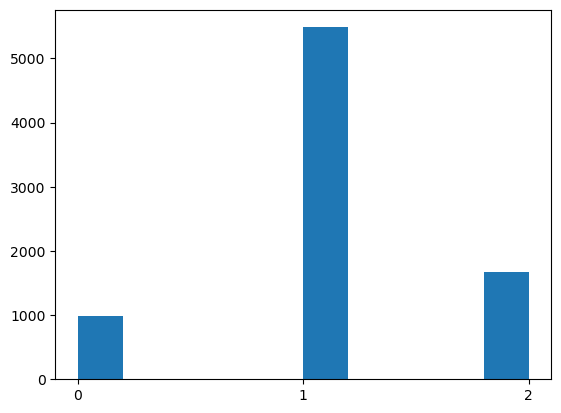

In [32]:
plt.hist(df['Topic_NMF'])
plt.xticks ([0,1,2]);

In [33]:
topic_1 = df[df['Topic_NMF']==0]
topic_1.shape

(990, 9)

In [34]:
topic_2 = df[df['Topic_NMF']==1]
topic_2.shape

(5486, 9)

In [35]:
topic_3 = df[df['Topic_NMF']==2]
topic_3.shape

(1676, 9)

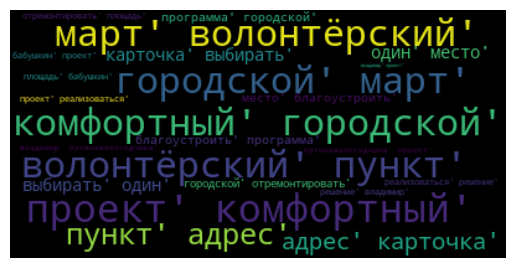

In [36]:
textt = ''.join(w for w in topic_1.pure_tokens)
wordcloud = WordCloud().generate(textt)
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')
plt.show()

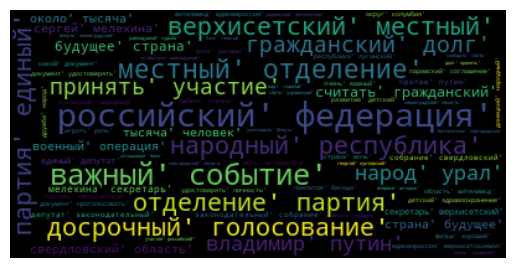

In [37]:
textt = ''.join(w for w in topic_2.pure_tokens)
wordcloud = WordCloud().generate(textt)
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')
plt.show()

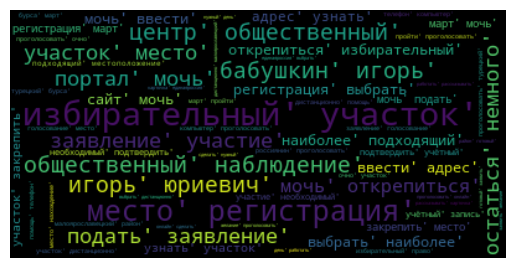

In [38]:
textt = ''.join(w for w in topic_3.pure_tokens)
wordcloud = WordCloud().generate(textt)
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')
plt.show()